In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [2]:
toyo_data=pd.read_csv('ToyotaCorolla - MLR.csv')
toyo_data.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


### Tasks:
#### 1.Perform exploratory data analysis (EDA) to gain insights into the dataset. Provide visualizations and summary statistics of the variables. Pre-process the data to apply the MLR.


##### Exploratory Data Analysis (EDA)

In [3]:
#dataset information***
toyo_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [4]:
#check missing value
toyo_data.isnull().sum()

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

In [5]:
#Describe dataset
toyo_data.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [6]:
#Convert Fuel Type to Numerical (Encoding)
df = pd.get_dummies(toyo_data, columns=['Fuel_Type'], drop_first=True)
df

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500,23,46986,90,0,2000,3,4,5,1165,True,False
1,13750,23,72937,90,0,2000,3,4,5,1165,True,False
2,13950,24,41711,90,0,2000,3,4,5,1165,True,False
3,14950,26,48000,90,0,2000,3,4,5,1165,True,False
4,13750,30,38500,90,0,2000,3,4,5,1170,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1431,7500,69,20544,86,0,1300,3,4,5,1025,False,True
1432,10845,72,19000,86,0,1300,3,4,5,1015,False,True
1433,8500,71,17016,86,0,1300,3,4,5,1015,False,True
1434,7250,70,16916,86,0,1300,3,4,5,1015,False,True


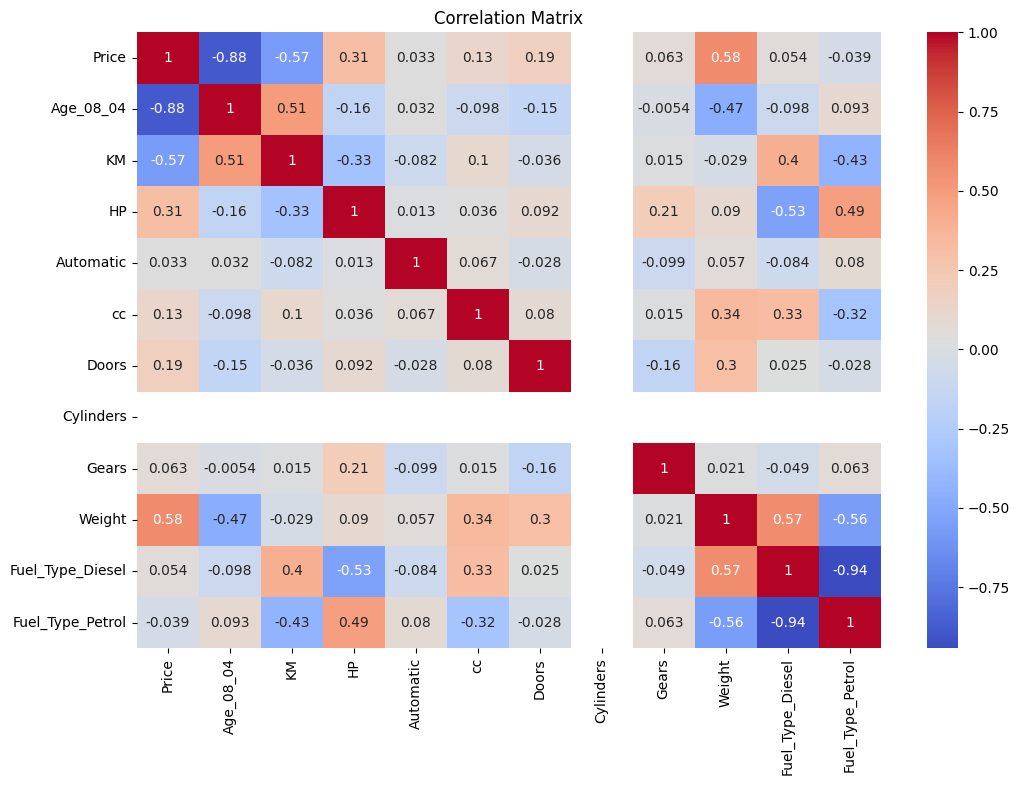

In [7]:
#correlation Matrix in visulzation
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

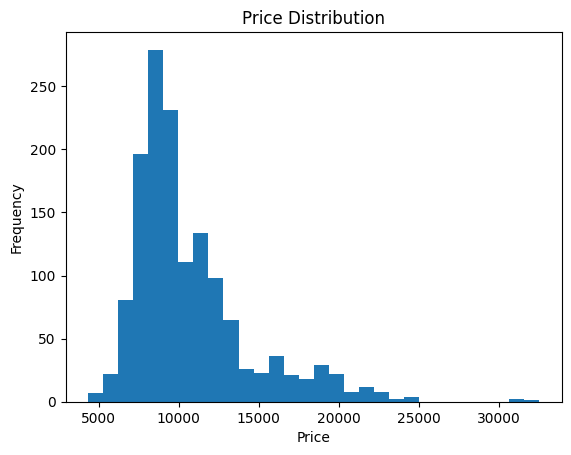

In [8]:
#Price Distribution
plt.hist(df['Price'], bins=30)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

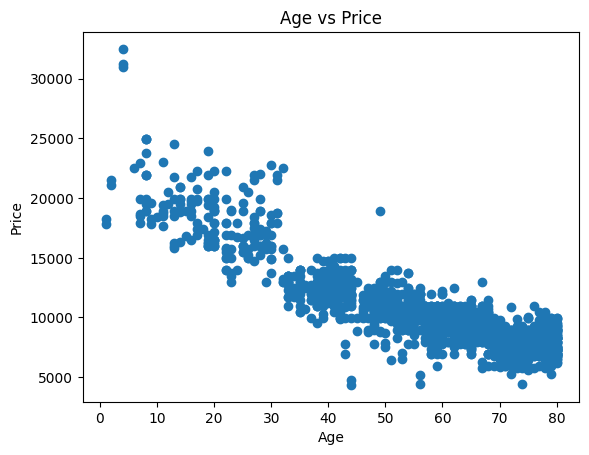

In [9]:
#scatter chart in Age Vs Price
plt.scatter(df['Age_08_04'], df['Price'])
plt.xlabel("Age")
plt.ylabel("Price")
plt.title("Age vs Price")
plt.show()

#### 2.Split the dataset into training and testing sets (e.g., 80% training, 20% testing).

In [10]:
#split the dataset
X = df.drop('Price', axis=1)
y = df['Price']

In [11]:
#Train Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
#Feature scaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### 3. Build a multiple linear regression model using the training dataset. Interpret the coefficients of the model. Build a minimum of 3 different models.

In [13]:
#Model 1: Basic Linear Regression
model1 = LinearRegression()

model1.fit(X_train_scaled, y_train)

y_pred1 = model1.predict(X_test_scaled)

In [14]:
#Coefficients Interpretation
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model1.coef_
})

print(coefficients)

             Feature   Coefficient
0          Age_08_04 -2.267295e+03
1                 KM -6.116544e+02
2                 HP  2.083499e+02
3          Automatic  3.439713e+01
4                 cc -1.416192e+01
5              Doors -5.746780e+01
6          Cylinders -2.842171e-13
7              Gears  1.093404e+02
8             Weight  1.316818e+03
9   Fuel_Type_Diesel -2.172217e+01
10  Fuel_Type_Petrol  4.580477e+02


In [15]:
#Model 2: Ridge Regression
ridge = Ridge(alpha=1)

ridge.fit(X_train_scaled, y_train)

y_pred2 = ridge.predict(X_test_scaled)

In [16]:
#Model 3: Lasso Regression
lasso = Lasso(alpha=0.1)

lasso.fit(X_train_scaled, y_train)

y_pred3 = lasso.predict(X_test_scaled)

#### 4.Evaluate the performance of the model using appropriate evaluation metrics on the testing dataset.



In [17]:
#Linear Regression Evaluation
print("Linear Regression")

print("R2 Score:", r2_score(y_test, y_pred1))
print("MSE:", mean_squared_error(y_test, y_pred1))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred1)))

Linear Regression
R2 Score: 0.8348888040611081
MSE: 2203043.823143704
RMSE: 1484.265415329652


In [18]:
#Ridge Regression Evaluation
print("Ridge Regression")

print("R2 Score:", r2_score(y_test, y_pred2))
print("MSE:", mean_squared_error(y_test, y_pred2))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred2)))

Ridge Regression
R2 Score: 0.8350462635431569
MSE: 2200942.8745232876
RMSE: 1483.5575063081606


In [19]:
#Lasso Regression Evaluation
print("Lasso Regression")

print("R2 Score:", r2_score(y_test, y_pred3))
print("MSE:", mean_squared_error(y_test, y_pred3))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred3)))

Lasso Regression
R2 Score: 0.8349116135580272
MSE: 2202739.4808426816
RMSE: 1484.1628889184237


#### 5.Apply Lasso and Ridge methods on the model.

In [20]:
results = pd.DataFrame({
    'Model':['Linear Regression','Ridge','Lasso'],
    'R2 Score':[
        r2_score(y_test,y_pred1),
        r2_score(y_test,y_pred2),
        r2_score(y_test,y_pred3)
    ],
    'RMSE':[
        np.sqrt(mean_squared_error(y_test,y_pred1)),
        np.sqrt(mean_squared_error(y_test,y_pred2)),
        np.sqrt(mean_squared_error(y_test,y_pred3))
    ]
})

print(results)

               Model  R2 Score         RMSE
0  Linear Regression  0.834889  1484.265415
1              Ridge  0.835046  1483.557506
2              Lasso  0.834912  1484.162889


### Interview Questions:
#### 1.What is Normalization & Standardization and how is it helpful?


#### 2.What techniques can be used to address multicollinearity in multiple linear regression?

##### Techniques to address multicollinearity in Multiple Linear Regression: